#### **Experiment No. 1**
#### **Experiment Name - Real-World Data Collection, Cleaning and Preprocessing using Python**

#### **Steps**

##### **NAME : Atul Krishna**
##### **COURSE : B.Tech CSE**
##### **SECTION - B**
##### **SUBJECT : Mastery in Data Analytics and Visualizations and Career Advancement**
##### **ROLL NO. : 14**
##### **CU ID : CU24250231**

##### **1. Download a real-world dataset such as the Titanic Survival Dataset or IBM HR Employee Attrition Dataset from Kaggle.**

In [24]:
from google.colab import files
uploaded = files.upload()  # select your Titanic CSV when prompted

import os
print(os.listdir())  # confirm the exact filename

Saving titanic[1].csv to titanic[1] (1).csv
['.config', 'titanic[1] (1).csv', 'titanic[1].csv', 'sample_data']


#####**2. Import the required libraries (Pandas, NumPy, Matplotlib, and Seaborn).**

In [25]:
# Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All required libraries imported successfully!")

All required libraries imported successfully!


#####**3. Load the dataset into a Pandas DataFrame and inspect its structure using head(), info(), and describe().**

In [26]:
df = pd.read_csv("titanic[1].csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (418, 12)


In [27]:
# Inspecting the dataset

print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Description:")
display(df.describe())

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB

Statistical Description:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


#####**4. Identify missing values and handle them using appropriate techniques such as mean, median, mode, or row/column removal.**

In [28]:
# Identifying and handling missing values

print("Missing values before treatment:")
print(df.isnull().sum())

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because a large proportion of values are missing
df.drop("Cabin", axis=1, inplace=True)

print("\nMissing values after treatment:")
print(df.isnull().sum())

Missing values before treatment:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Missing values after treatment:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64


#####**5. Detect and remove duplicate records to ensure data consistency.**

In [29]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (418, 11)


#####**6. Standardize inconsistent categorical values and convert them into numerical format using Label Encoding or One-Hot Encoding.**

In [30]:
# Standardize categorical values and encode them

# Remove unnecessary spaces and standardize text
df["Sex"] = df["Sex"].str.strip().str.lower()
df["Embarked"] = df["Embarked"].str.strip().str.upper()

# One-Hot Encoding for categorical variables
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

print("Dataset after categorical encoding:")
display(df.head())

Dataset after categorical encoding:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,892,0,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,1,1,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,0,0,1
2,894,0,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,1,1,0
3,895,0,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,1,0,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,0,0,1


#####**7. Identify outliers in numerical features using Box Plots and the IQR method, and treat them appropriately.**

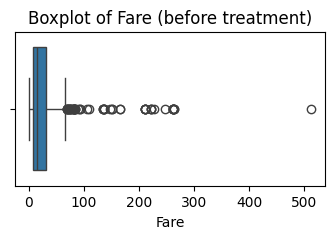

In [35]:
plt.figure(figsize=(4,2))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare (before treatment)")
plt.show()

Lower bound: -27.5105 Upper bound: 66.9063
Outliers: 0


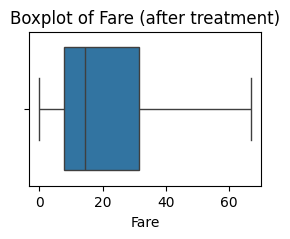

In [38]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound, "Upper bound:", upper_bound)
print("Outliers:", ((df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)).sum())

df['Fare'] = np.where(df['Fare'] > upper_bound, upper_bound, df['Fare'])
df['Fare'] = np.where(df['Fare'] < lower_bound, lower_bound, df['Fare'])

plt.figure(figsize=(3,2))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare (after treatment)")
plt.show()

#####**8. Normalize or standardize numerical attributes to bring them to a common scale.**

In [39]:
# Normalize/standardize numerical attributes
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Age', 'Fare']
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].describe()

,Age,Fare
count,4.180000e+02,4.170000e+02
mean,5.524555e-17,-3.194886e-17
std,1.001198e+00,1.001201e+00
min,-2.319355e+00,-1.163741e+00
25%,-5.200968e-01,-7.913940e-01
50%,-2.048523e-01,-4.821158e-01
75%,4.847449e-01,3.217226e-01
max,3.656893e+00,1.991397e+00


#####**9. Perform feature engineering by creating new attributes (e.g., Family Size, Age Group, or Income Category).**

In [40]:
# Feature engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 19, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

df[['FamilySize', 'IsAlone', 'AgeGroup']].head()

,FamilySize,IsAlone,AgeGroup
0,1,1,Child
1,2,0,Child
2,1,1,Child
3,1,1,NaN
4,3,0,NaN


#####**10. Save the cleaned and preprocessed dataset as a new CSV file for further analysis.**

In [41]:
df.to_csv("Titanic_Cleaned.csv", index=False)

from google.colab import files
files.download("Titanic_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Questions & Answers
1. Why is data preprocessing considered one of the most important phases in data analytics?

Data preprocessing is the process of cleaning, transforming, and preparing raw data before analysis or machine learning.

It is important because real-world data may contain missing values, duplicate records, inconsistent formats, categorical values, and outliers. If these problems are not handled, they can produce incorrect analysis and reduce the accuracy of machine learning models.

Main benefits:

* Improves data quality and consistency.
* Handles missing and incorrect values.
* Removes duplicate and irrelevant records.
* Converts categorical data into numerical form.
* Reduces the effect of outliers.
* Makes data suitable for machine learning algorithms.
* Improves model accuracy and reliability.

Example: If an employee's salary is missing, directly calculating the average salary without treating the missing value may produce incorrect results.

2. Explain different methods of handling missing values with suitable examples.

Missing values are data entries where no value is available. They can be handled using several techniques:

(a) Mean Imputation:
Replace missing numerical values with the mean of the column.

Example:
* Age = [20, 25, NaN, 30]
* Mean = 25
* After imputation = [20, 25, 25, 30]

(b) Median Imputation:
Replace missing values with the median. It is useful when the data contains outliers.

(c) Mode Imputation:
Replace missing categorical values with the most frequently occurring value.

Example:
* Department = [IT, HR, IT, NaN]
* Mode = IT

(d) Row Removal:
Remove rows containing missing values when only a small number of records are affected.

(e) Column Removal:
Remove an entire column if a very large percentage of its values are missing and the feature is not important.

The method should be selected based on the type, amount, and importance of the missing data.

3. Differentiate between Label Encoding and One-Hot Encoding.
| Label Encoding                                                         | One-Hot Encoding                                                 |
| ---------------------------------------------------------------------- | ---------------------------------------------------------------- |
| Converts categories into integer values.                               | Converts each category into a separate binary column.            |
| Example: Male = 0, Female = 1.                                         | Example: Male → `[1,0]`, Female → `[0,1]`.                       |
| Usually creates only one additional column.                            | Creates multiple columns.                                        |
| Suitable for ordinal categories where order has meaning.               | Suitable for nominal categories where there is no natural order. |
| May introduce an artificial numerical relationship between categories. | Avoids implying an order between categories.                     |

Example:
* For Department = [HR, IT, Sales]

Label Encoding:
* HR = 0
* IT = 1
* Sales = 2

One-Hot Encoding:
* HR    IT    Sales
* 1     0     0
* 0     1     0
* 0     0     1

4. What are outliers? How can they affect analytical results?

Outliers are observations that are significantly different from the majority of values in a dataset.

For example, if most employee salaries are between ₹20,000 and ₹80,000 but one record has a salary of ₹10,00,000, it may be an outlier.

Outliers can be detected using:
* Box plots
* IQR (Interquartile Range) method
* Z-score

Outliers can:
* Distort the mean and standard deviation.
* Affect statistical analysis.
* Produce misleading visualizations.
* Reduce the performance of some machine learning models.
* Influence regression and clustering results.

Therefore, outliers should be investigated and appropriately treated, rather than automatically removed.

5. Explain the difference between normalization and standardization.

Both techniques are used to bring numerical features to comparable scales, but they work differently.

Normalization:
Normalization generally transforms values to a fixed range, commonly 0 to 1.

Formula:

$$ X_{normalized} = \frac{X-X_{min}}{X_{max}-X_{min}} $$

Example: If the minimum age is 20 and maximum age is 60, an age of 40 becomes:

$$ \frac{40-20}{60-20}=0.5 $$

Standardization:
Standardization transforms data so that it has approximately mean = 0 and standard deviation = 1.

Formula:

$$ X_{standardized} = \frac{X-\mu}{\sigma} $$

| Normalization                          | Standardization                                       |
| -------------------------------------- | ----------------------------------------------------- |
| Usually scales values to 0–1.          | Centers data around mean 0.                           |
| Uses minimum and maximum values.       | Uses mean and standard deviation.                     |
| Sensitive to extreme values.           | Generally less dependent on the min/max range.        |
| Useful when a fixed range is required. | Commonly used for many statistical and ML algorithms. |

6. Why should duplicate records be removed before analysis?

Duplicate records are repeated observations representing the same data.

They should be removed because duplicates can:
* Artificially increase the number of observations.
* Bias statistical calculations.
* Give incorrect frequency and count values.
* Affect mean, median, and other statistics.
* Cause machine learning models to learn repeated information.
* Reduce the overall quality and reliability of the dataset.

Example:
If the same employee appears three times in an employee dataset, the employee may have three times the influence of other employees during analysis.

In Pandas, duplicates can be detected and removed using:
* df.drop_duplicates()

7. What is feature engineering? Give two practical examples.

Feature engineering is the process of creating new meaningful features from existing data to improve analysis or machine learning performance.

It helps convert raw attributes into more useful information.

Example 1 – Family Size in Titanic Dataset:

Using SibSp and Parch:

$$ FamilySize = SibSp + Parch + 1 $$

This represents the total number of family members travelling with the passenger.

Example 2 – Age Group:

The continuous Age variable can be converted into categories:
* 0–12     → Child
* 13–19    → Teenager
* 20–59    → Adult
* 60+      → Senior

These new features may make patterns easier to identify.

8. Which preprocessing techniques would you apply to the IBM HR Employee Attrition dataset and why?

For the IBM HR Employee Attrition dataset, I would apply the following preprocessing techniques:
* Missing Value Handling – Identify missing values and replace them using appropriate methods such as median or mode, or remove records when justified.
* Duplicate Removal – Remove duplicate employee records to prevent repeated observations from affecting the analysis.
* Categorical Encoding – Convert categorical attributes such as Gender, Department, JobRole, and BusinessTravel into numerical form using One-Hot Encoding or Label Encoding, depending on the feature.
* Outlier Detection – Use box plots and the IQR method to identify unusual values in numerical attributes such as MonthlyIncome, Age, and TotalWorkingYears.
* Feature Scaling – Normalize or standardize numerical features so that variables with different ranges can be compared effectively.
* Feature Engineering – Create useful features such as Age Group, Income Category, Years per Company, or Job Experience Group.
* Target Encoding/Preparation – Convert the Attrition target variable into a suitable numerical representation, such as Yes = 1 and No = 0.

These techniques improve the quality, consistency, and suitability of the dataset for analytics and machine learning.

9. How does poor-quality data affect machine learning model performance?

Poor-quality data can significantly reduce the performance and reliability of a machine learning model.

Problems such as missing values, incorrect data, duplicates, inconsistent formats, outliers, and noisy features can cause the model to learn incorrect patterns.

Effects include:
* Lower prediction accuracy.
* Incorrect or biased predictions.
* Overfitting or underfitting.
* Increased training time.
* Unstable model performance.
* Incorrect conclusions from the data.
* Poor generalization to new/unseen data.

Example:
If an employee dataset contains incorrect salary values, a model predicting employee attrition may learn misleading relationships between salary and attrition.

Therefore, high-quality and properly preprocessed data is essential for building reliable machine learning models.

10. Name any three Python libraries commonly used for data preprocessing.

Three commonly used Python libraries are:
* Pandas – Used for data loading, cleaning, manipulation, missing-value handling, and DataFrame operations.
* NumPy – Used for numerical computations, arrays, mathematical operations, and handling numerical data.
* Scikit-learn – Provides preprocessing tools such as encoding, normalization, standardization, imputation, and feature scaling.

Other commonly used libraries include Matplotlib and Seaborn for data visualization, which are useful for identifying patterns and outliers during preprocessing.